# 01 — The measuring instrument

Every severity number in the thesis comes from one satellite: a multi-state credit
transition model (current / 30 DPD / 60 DPD / default / prepay) built from
**hard-monotone I-spline GAMs** with adverse-tail extrapolation and a
**cross-state projection** layer. This notebook loads the cached instrument and
demonstrates the two properties everything downstream depends on:

1. **Monotonicity** — a worse macro input can never produce a safer prediction.
2. **Instrument choice matters** — unconstrained benchmarks (RF/EBM) compress
   severity outside the training support.

The instrument is validated in its own chapters (constraint dial, COVID
out-of-support test, coherence projection); here we only *inspect* it.

In [1]:
import os, sys, pickle
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

# Find the folder that contains the `multistate` package (works from
# bl225msc/ or from a self-contained thesis_demo/ bundle).
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "multistate").is_dir())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
if (ROOT / "data" / "fed").is_dir():
    os.environ.setdefault("THESIS_DATA_DIR", str(ROOT / "data"))
RESULTS = ROOT / "results"
print(f"root: {ROOT}")

def load_csv(path, produced_by):
    path = Path(path)
    if not path.exists():
        print(f"[missing] {path}\n  produce it with:\n  {produced_by}")
        return None
    return pd.read_csv(path)

def load_pickle(path, produced_by):
    path = Path(path)
    if not path.exists():
        print(f"[missing] {path}\n  produce it with:\n  {produced_by}")
        return None
    with path.open("rb") as fh:
        return pickle.load(fh)

root: c:\Users\user\OneDrive\Desktop\thesis_clean\bl225msc\thesis_demo


In [2]:
dataset = load_pickle(RESULTS / "cache" / "dataset.pkl",
                      "python -m multistate.run --dataset-cache results/cache/dataset.pkl")
satellite = load_pickle(RESULTS / "cache" / "satellite.pkl",
                        "python -m multistate.scengen.frontier --dataset-cache results/cache/dataset.pkl --model-cache results/cache/satellite.pkl --n-paths 5")
if dataset is not None:
    print(f"features: {len(dataset.features)} | train rows: {len(dataset.train):,} | test A rows: {len(dataset.test_a):,}")
if satellite is not None:
    print(type(satellite).__name__, "wrapping", type(satellite.base).__name__)

features: 17 | train rows: 425,156 | test A rows: 31,982
CrossStateProjection wrapping SequentialCreditPrepayGAM


## Live check: the monotone stress response

Take a few hundred real Test-A rows, sweep the unemployment input upward, and watch
the predicted default probability. For the constrained GAM this curve **cannot**
slope down — by construction, not by luck. This is the property that makes the
satellite a valid measuring device for scenario severity.

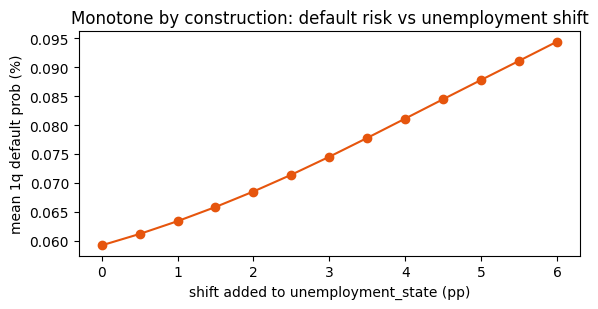

monotone non-decreasing: True


In [3]:
if dataset is not None and satellite is not None:
    from multistate.data import STATE_TO_INDEX
    unemp = next((f for f in dataset.features if "unemp" in f.lower()), None)
    if unemp is None:
        print("no unemployment feature found in", dataset.features)
    else:
        base = dataset.test_a[dataset.test_a["origin_state"].eq("current")].head(400).copy()
        shifts = np.linspace(0.0, 6.0, 13)
        curve = []
        for shift in shifts:
            frame = base.copy()
            frame[unemp] = frame[unemp] + shift
            probs = satellite.predict_proba(frame)
            curve.append(probs[:, STATE_TO_INDEX["default"]].mean())
        plt.figure(figsize=(6, 3.2))
        plt.plot(shifts, np.array(curve) * 100, marker="o", color="#e6550d")
        plt.xlabel(f"shift added to {unemp} (pp)"); plt.ylabel("mean 1q default prob (%)")
        plt.title("Monotone by construction: default risk vs unemployment shift")
        plt.tight_layout(); plt.show()
        print("monotone non-decreasing:", bool(np.all(np.diff(curve) >= -1e-12)))

## Loaded result: the instrument-sensitivity ablation

Same scenario paths, three instruments. The benchmarks *agree on direction* but
compress the severe scenario's H12 PD from ~19.4% to ~14% — flat extrapolation
outside training support. This is why the constrained GAM is the instrument:
not predictive superiority, but a provably preserved response to severity.

In [4]:
table = load_csv(RESULTS / "scengen" / "instrument_sensitivity_sanity.csv",
                 "assembled from frontier runs with --satellite gam / rf / ebm on the shared 25-path set")
if table is not None:
    display(table)

,instrument,generator,anchor_pd_h12,sample_pd_h12_median,sample_pd_h12_p95,sample_pd_h12_max
0,projected_gam,graph_block,0.193969,0.206135,0.401756,0.440299
1,projected_gam,graph_block_do,0.193969,0.124578,0.134275,0.135854
2,projected_gam,var_gaussian,0.193969,0.181285,0.344018,0.393331
3,projected_gam,var_gaussian_do,0.193969,0.120913,0.136571,0.139712
4,rf,graph_block,0.139494,0.139303,0.166551,0.168810
5,rf,graph_block_do,0.139494,0.097308,0.105114,0.110549
6,rf,var_gaussian,0.139494,0.134179,0.153486,0.156832
7,rf,var_gaussian_do,0.139494,0.097872,0.111232,0.114002
8,ebm,graph_block,0.144415,0.150611,0.197808,0.200327
9,ebm,graph_block_do,0.144415,0.077884,0.085446,0.090859


**Takeaway.** The satellite is the thesis's ruler. Chapters 4–5 are its
calibration certificate; this notebook is the 60-second demonstration that the
ruler measures what the scenario experiments need it to measure.